In [2]:
import sys
!{sys.executable} -m pip install matplotlib seaborn pandas numpy

In [3]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
-O fonts/NanumGothic.ttf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지


In [4]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(13) # 숙제 번호 13을 시드로 (재현 가능성)
N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28} # 장르별 평균 어절 수
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)
texts = pd.DataFrame({
'장르': genre,
'어절수': words,
'음절수': syllables,
'읽기시간': read_time,
'난이도': difficulty,
})
# 연도별 신문/소설의 외래어 비율(%) (가상 데이터)
trends = pd.DataFrame({
'연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
'뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
'소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})

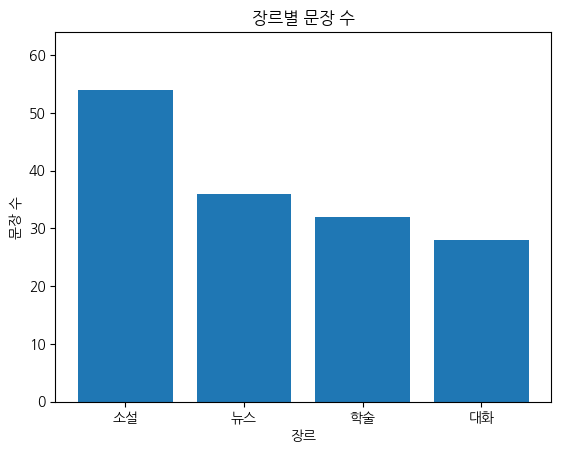

In [5]:
counts = texts["장르"].value_counts()

fig, ax = plt.subplots()

ax.bar(counts.index, counts.values)

ax.set_title("장르별 문장 수")
ax.set_xlabel("장르")
ax.set_ylabel("문장 수")
ax.set_ylim(0, counts.max() + 10)

plt.show()

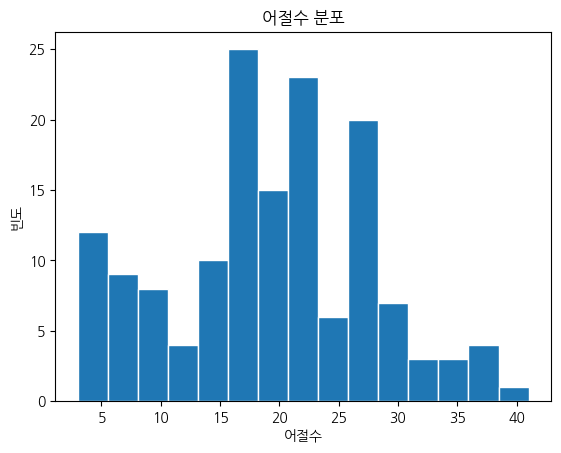

In [6]:
fig, ax = plt.subplots()

ax.hist(
    texts["어절수"],
    bins=15,
    edgecolor="white"
)

ax.set_title("어절수 분포")
ax.set_xlabel("어절수")
ax.set_ylabel("빈도")

plt.show()


 어절 수는 대체로 10~30개 구간에 많이 분포한다.

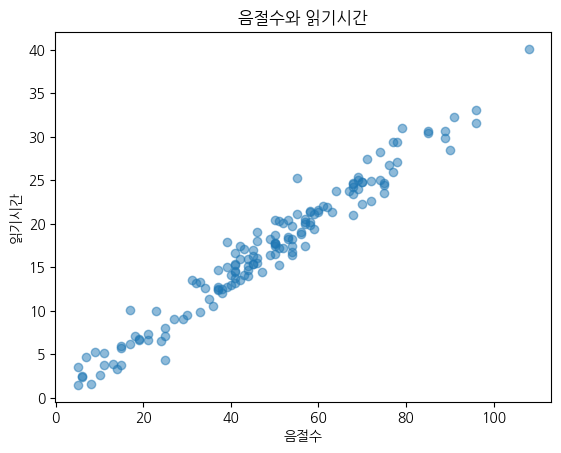

In [7]:
fig, ax = plt.subplots()

ax.scatter(
    texts["음절수"],
    texts["읽기시간"],
    alpha=0.5
)

ax.set_title("음절수와 읽기시간")
ax.set_xlabel("음절수")
ax.set_ylabel("읽기시간")

plt.show()


음절 수가 증가할수록 읽기시간도 증가하는 우상향 관계가 나타난다.

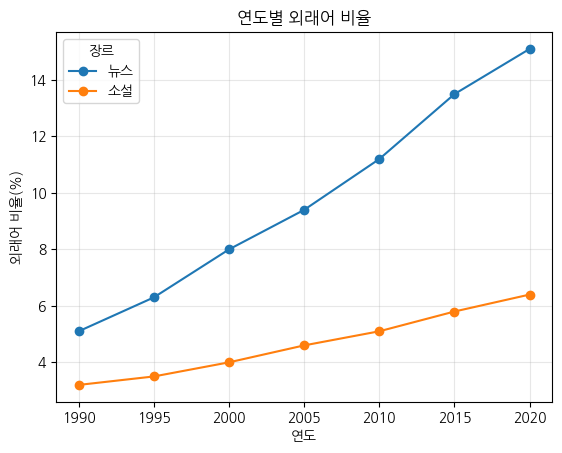

In [8]:
fig, ax = plt.subplots()

ax.plot(
    trends["연도"],
    trends["뉴스"],
    marker="o",
    label="뉴스"
)

ax.plot(
    trends["연도"],
    trends["소설"],
    marker="o",
    label="소설"
)

ax.set_title("연도별 외래어 비율")
ax.set_xlabel("연도")
ax.set_ylabel("외래어 비율(%)")

ax.legend(title="장르")
ax.grid(True, alpha=0.3)

plt.show()


두 장르 모두 증가하지만 뉴스의 증가 속도가 훨씬 빠르다.

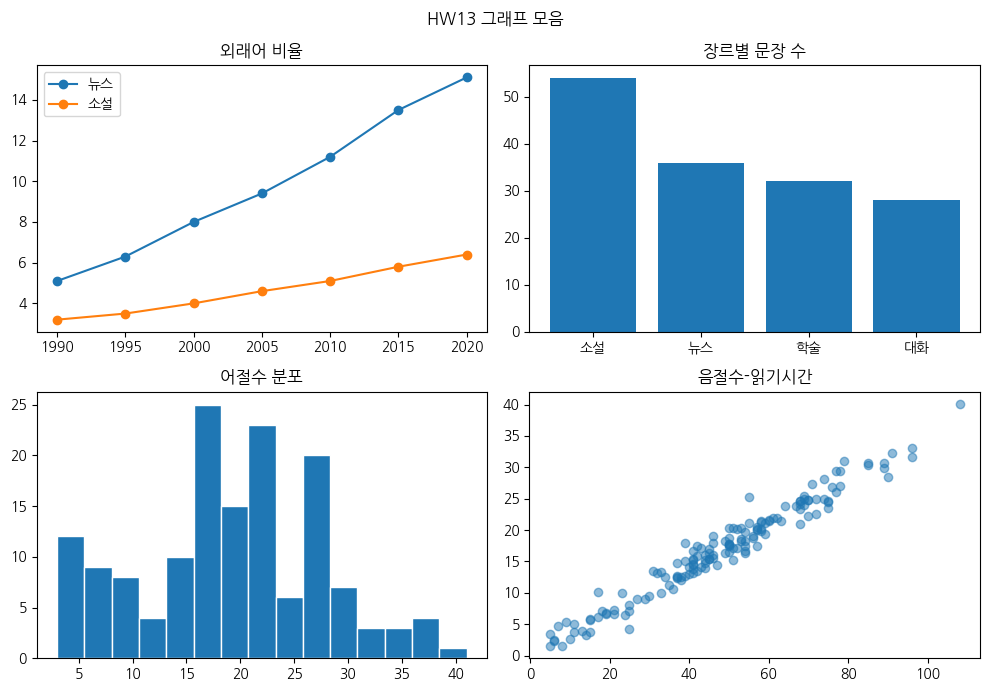

In [9]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7)
)

# 선 그래프
axes[0,0].plot(
    trends["연도"],
    trends["뉴스"],
    marker="o",
    label="뉴스"
)
axes[0,0].plot(
    trends["연도"],
    trends["소설"],
    marker="o",
    label="소설"
)
axes[0,0].legend()
axes[0,0].set_title("외래어 비율")

# 막대그래프
counts = texts["장르"].value_counts()
axes[0,1].bar(
    counts.index,
    counts.values
)
axes[0,1].set_title("장르별 문장 수")

# 히스토그램
axes[1,0].hist(
    texts["어절수"],
    bins=15,
    edgecolor="white"
)
axes[1,0].set_title("어절수 분포")

# 산점도
axes[1,1].scatter(
    texts["음절수"],
    texts["읽기시간"],
    alpha=0.5
)
axes[1,1].set_title("음절수-읽기시간")

fig.suptitle("HW13 그래프 모음")

fig.tight_layout()

fig.savefig(
    "hw13_subplots.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

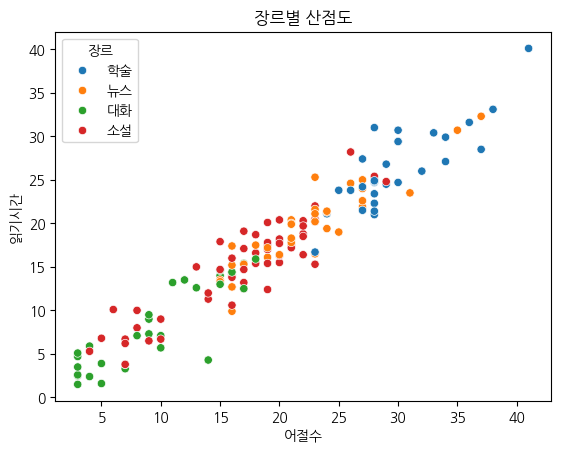

In [10]:
import seaborn as sns

fig, ax = plt.subplots()

sns.scatterplot(
    data=texts,
    x="어절수",
    y="읽기시간",
    hue="장르",
    ax=ax
)

ax.set_title("장르별 산점도")

plt.show()

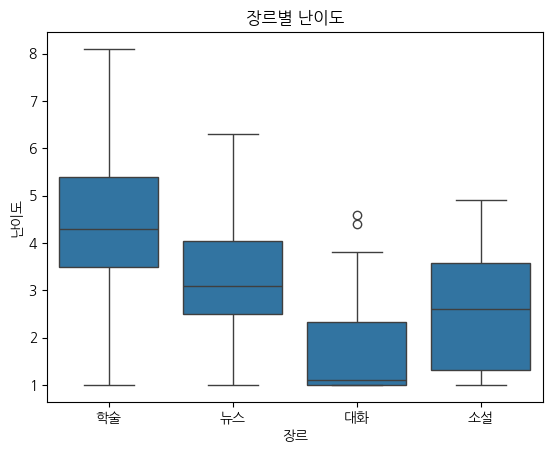

In [11]:
fig, ax = plt.subplots()

sns.boxplot(
    data=texts,
    x="장르",
    y="난이도",
    ax=ax
)

ax.set_title("장르별 난이도")

plt.show()

학술 장르가 가장 높은 난이도를 보이며, 장르에 따라 분포의 퍼짐 정도도 다르게 나타난다.

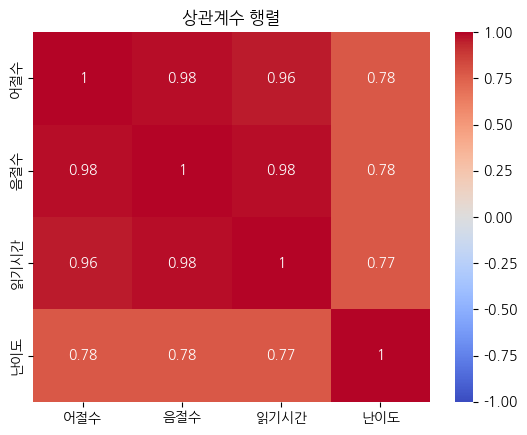

In [12]:
corr = texts[
    ["어절수", "음절수", "읽기시간", "난이도"]
].corr()

fig, ax = plt.subplots()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=ax
)

ax.set_title("상관계수 행렬")

plt.show()

음절수와 읽기시간의 상관관계가 가장 높다(읽기시간이 음절 수를 기반으로 생성되었기 때문)

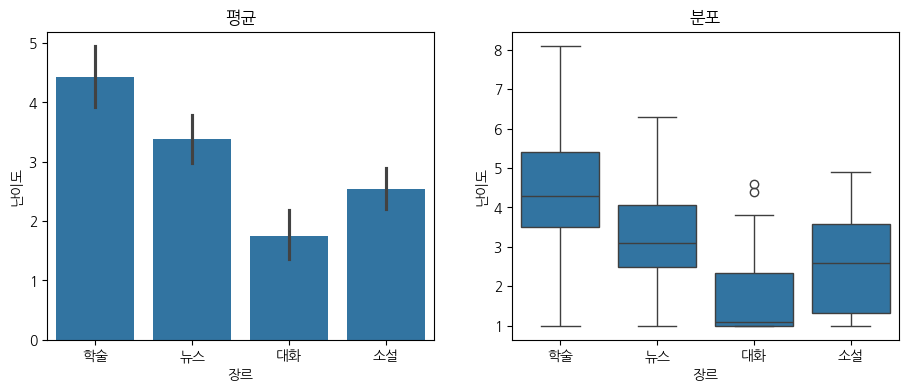

In [13]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(11,4)
)

sns.barplot(
    data=texts,
    x="장르",
    y="난이도",
    ax=axes[0]
)

sns.boxplot(
    data=texts,
    x="장르",
    y="난이도",
    ax=axes[1]
)

axes[0].set_title("평균")
axes[1].set_title("분포")

plt.show()

막대그래프는 평균만 보여주므로 데이터의 분산과 이상치를 숨김: 평균이 비슷한 두 장르라도 한쪽은 값이 고르게 분포하고 다른 쪽은 매우 넓게 퍼져 있을 수 있는데, 상자그림은 이러한 차이를 확인할 수 있다

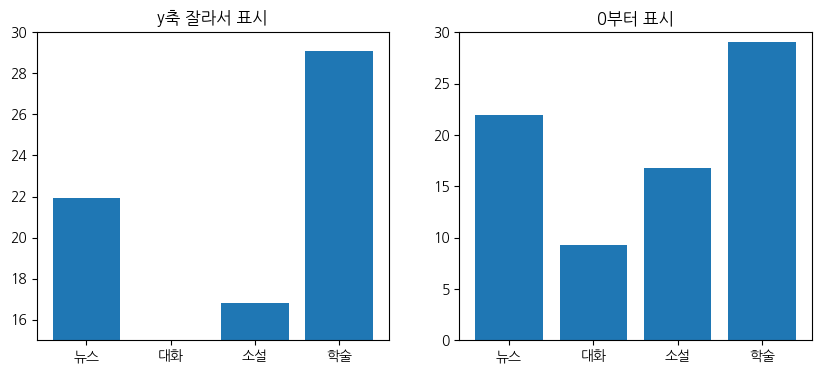

In [14]:
avg_words = (
    texts.groupby("장르")["어절수"]
    .mean()
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(10,4)
)

axes[0].bar(
    avg_words.index,
    avg_words.values
)
axes[0].set_ylim(15, 30)
axes[0].set_title("y축 잘라서 표시")

axes[1].bar(
    avg_words.index,
    avg_words.values
)
axes[1].set_ylim(0, 30)
axes[1].set_title("0부터 표시")

plt.show()

y축을 자르면 실제 차이보다 훨씬 크게 보이는 착시가 발생한다. 막대 그래프는 막대의 길이 자체를 비교하는 그래프이므로 기준점인 0에서 시작해야 왜곡 없이 비교할 수 있다.

생성형 AI 사용 링크: https://chatgpt.com/share/6a283f3e-4358-8320-a415-a10076cd9b3a